In [12]:
import os
import matplotlib.pyplot as plt
from tabulate import tabulate
from utils.plot import plot_preds_and_error

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

In [13]:
# Number of points generated for the Lorenz time series
npoints = 1000

# Lorenz system parameters
sigma, rho, beta = 10, 28, 8 / 3

# Initial conditions
x, y, z = [0], [-0.01], [9]

# Integration step size
h = 0.01

# Solve the Lorenz system using Euler integration
for _ in range(npoints - 1):
    x_t, y_t, z_t = x[-1], y[-1], z[-1]

    x.append(x_t + h * sigma * (y_t - x_t))
    y.append(y_t + h * (-y_t - z_t * x_t + rho * x_t))
    z.append(z_t + h * (-beta * z_t + x_t * y_t))

# Combine the three coordinates into a single dataset
dataset = np.column_stack((x, y, z))

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

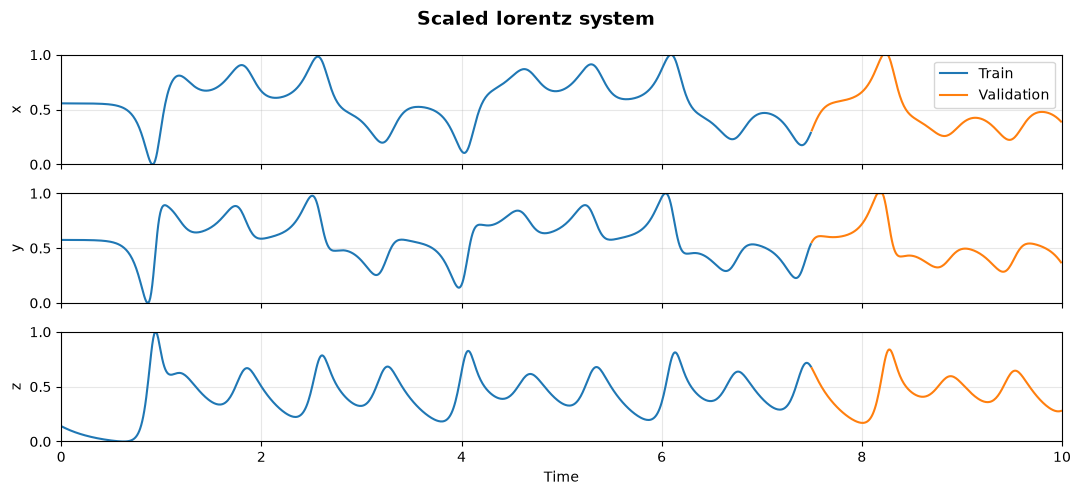

In [14]:
# Plot the scaled Lorentz system
time = np.arange(npoints) * h
time_tr = time[:len(train_scaled)]
time_val = time[len(train_scaled):]

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)

for ax in axes:
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)


axes[0].plot(time_tr, train_scaled[:, 0], label="Train")
axes[0].plot(time_val, val_scaled[:, 0], label="Validation")
axes[0].legend()
axes[0].set_ylabel("x")

axes[1].plot(time_tr, train_scaled[:, 1])
axes[1].plot(time_val, val_scaled[:, 1])
axes[1].set_ylabel("y")

axes[2].plot(time_tr, train_scaled[:, 2])
axes[2].plot(time_val, val_scaled[:, 2])
axes[2].set_ylabel("z")
axes[2].set_xlabel("Time")
axes[2].set_xlim(0, 10)

fig.suptitle("Scaled lorentz system", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
def create_sequences(data, window_size, horizon):
    """
    Creates input-output sequences for time series forecasting.

    Each input contains the previous window_size points, and each output
    contains the next horizon points to predict.
    """
    n_data = len(data)
    x = []
    y = []

    # Slide a window over the time series
    for i in range(window_size, n_data - horizon + 1):

        # Input sequence: previous window_size points
        x.append(data[i - window_size:i])

        # Target sequence: next horizon points
        y.append(data[i:i + horizon])

    return np.array(x), np.array(y)

# Independent-chanel VQC

First, we will use and independent VQC per each variable. Each VQC will consist on the aplication of a angle encoding feature map $U_{enc}$ and an ansantz $U_{var}(\theta)$. The chosen architectures are angle encoding via $R_y$ rotations for the feature map, and strongly entangling layer with $R_z, R_y, R_z$ rotations and circular entangling layer for the ansatz. Thus, output per chanel will be given by:

$$
Z_c = \langle 0^{\otimes n}|U_{enc}^\dagger U_{var}^\dagger (\theta) Z_0 U_{var} (\theta) U_{enc} |0^{\otimes n} \rangle 
$$

Finally, by collecting all the chanels we obtain the raw quantum output vector:

$$
Z = [Z_1, ... ,Z_C] \in [-1, 1]^C
$$

which can be rescaled to match the normalized data domain by computing:

$$
\hat{Y} = (Z+1)/2
$$

In [16]:
# Create the sequences
window_size = 5
horizon = 1
batch_size = 128

x_tr, hor_tr = create_sequences(train_scaled, window_size, horizon)
x_val, hor_val = create_sequences(val_scaled, window_size, horizon)

# Convert to tensor
x_tr = torch.from_numpy(x_tr).double()
hor_tr = torch.from_numpy(hor_tr).double()

x_val = torch.from_numpy(x_val).double()
hor_val = torch.from_numpy(hor_val).double()

In [17]:
def create_channel_loader(x, y, channel, batch_size=128, shuffle=False):
    """
    Creates a DataLoader for one independent time series channel.
    """
    # Select only one channel
    x_channel = x[:, :, channel] # (n_samples, window_size)
    y_channel = y[:, :, channel] # (n_samples, horizon)

    dataset = TensorDataset(x_channel, y_channel)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return loader

In [18]:
# Create the data loaders
train_loader_x = create_channel_loader(x_tr, hor_tr, channel=0, batch_size=batch_size)
train_loader_y = create_channel_loader(x_tr, hor_tr, channel=1, batch_size=batch_size)
train_loader_z = create_channel_loader(x_tr, hor_tr, channel=2, batch_size=batch_size)

In [19]:
def angle_encoding(nqubits: int, inputs: list[float]) -> None:
    """
    Encodes classical input data into a quantum circuit using angle encoding 
    by applying Ry rotations with angle pi * input[i]
    """
    # Encode each classical value into one qubit
    for i in range(nqubits):
        qml.RY(np.pi * inputs[..., i], wires=i)

def QVC(nqubits: int, theta: list[float], reps: int) -> None:
    """
    Builds a variational quantum circuit.

    Each layer applies three parameterized rotations to every qubit:
    Rz -> Ry -> Rz.

    After the rotation block, a circular CNOT entangling layer is applied.
    """
    for rep in range(reps):
        # Rotation block
        for i in range(nqubits):
            base = rep * 3 * nqubits
            qml.RZ(theta[base + i], wires=i)
            qml.RY(theta[base + nqubits + i], wires=i)
            qml.RZ(theta[base + 2 * nqubits + i], wires=i)
        
        # Entangling block
        for i in range(nqubits-1):
            qml.CNOT(wires=[i, i+1])
        
        # Circular connection between last and first qubit
        qml.CNOT(wires=[nqubits-1, 0])

In [20]:
# Create the PennyLane QNode 
nqubits = window_size
nreps = 24
dev = qml.device("lightning.qubit", wires=nqubits)

def indep_chanel_vqc(inputs, theta):
    angle_encoding(nqubits, inputs)
    QVC(nqubits, theta, nreps)
    return qml.expval(qml.Z(0))

indep_chanel_vqc_node = qml.QNode(
    func=indep_chanel_vqc,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

In [21]:
# Define the dimensions of the weigths
weights = {"theta": (3 * nqubits * nreps,)}

# Create the class for the independent VQC model
class IndependentChannelVQC(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)

    def forward(self, x):
        z = self.qlayer(x)
        return (z + 1) / 2
    
# Build one independent model for each Lorenz channel
model_x = IndependentChannelVQC()
model_y = IndependentChannelVQC()
model_z = IndependentChannelVQC()

# Use double precision for compatibility with PennyLane
model_x.double()
model_y.double()
model_z.double()


# Select each channel independently
val_x = x_val[:, :, 0]  # shape: (n_samples, window_size)
val_y = x_val[:, :, 1]
val_z = x_val[:, :, 2]

val_hor_x = hor_val[:, :, 0]  # shape: (n_samples, horizon)
val_hor_y = hor_val[:, :, 1]
val_hor_z = hor_val[:, :, 2]


In [ ]:
### EXECUTION TIME: 105 MINS APROX ###

# Hyperparameters
epochs = 50
lr = 5e-4

# Mean squared error loss for regression
loss_fn = nn.MSELoss()

# Group loaders, validation datasets and models to train the three channels in the same loop
loaders = (train_loader_x, train_loader_y, train_loader_z)
models = (model_x, model_y, model_z)
val_windows = (val_x, val_y, val_z)
val_horizons = (val_hor_x, val_hor_y, val_hor_z)

histories = []

for loader, model, val_window, val_hor in zip(loaders, models, val_windows, val_horizons):
    print(30 * "#")
    print("Starting training")
    print(30 * "#")

    history = {"Loss": [], "Val loss": []}

    # Save the best model
    best_state = None
    best_val_loss = float("inf")

    # Define optimizer
    opt = torch.optim.Adam(params=model.parameters(), lr=lr)

    for epoch in range(epochs):

        #Training
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb.squeeze())
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        
        # Store average loss for this epoch
        epoch_loss /= len(loader)
        history["Loss"].append(epoch_loss)

        # Evaluation
        model.eval()
        with torch.no_grad():
            val_pred = model(val_window)
            val_loss = loss_fn(val_pred, val_hor.squeeze()).item()

        # Store val loss
        history["Val loss"].append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                name: params.detach().clone()
                for name, params in model.state_dict().items()
            }

        # Print training progress every 5 epochs
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")

    histories.append(history)
    if best_state is not None:
        model.load_state_dict(best_state)

In [ ]:
# Save the models
os.makedirs("models", exist_ok=True)

checkpoint = {
    "model_x": model_x.state_dict(),
    "model_y": model_y.state_dict(),
    "model_z": model_z.state_dict(),
    "histories": histories
}

torch.save(checkpoint, "models/independent_channel_vqc.pt")

In [ ]:
# Load the models
checkpoint = torch.load(
    "models/independent_channel_vqc.pt",
    map_location="cpu"
)

histories = checkpoint["histories"]

model_x = IndependentChannelVQC().double()
model_y = IndependentChannelVQC().double()
model_z = IndependentChannelVQC().double()

model_x.load_state_dict(checkpoint["model_x"])
model_y.load_state_dict(checkpoint["model_y"])
model_z.load_state_dict(checkpoint["model_z"])

<All keys matched successfully>

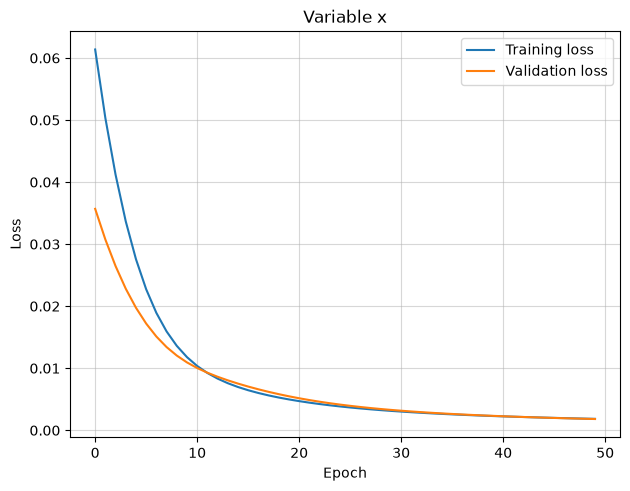

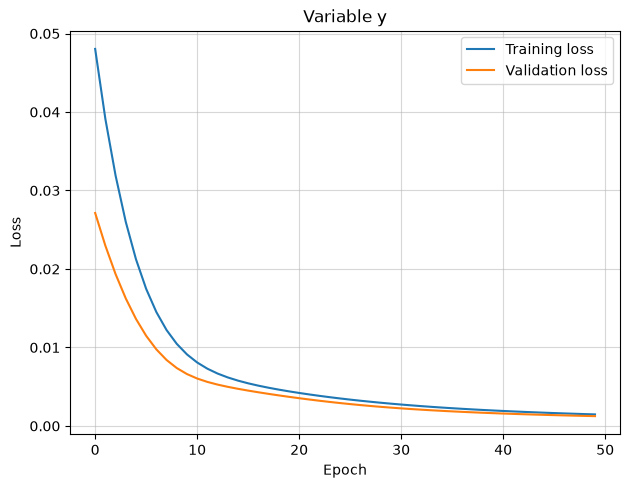

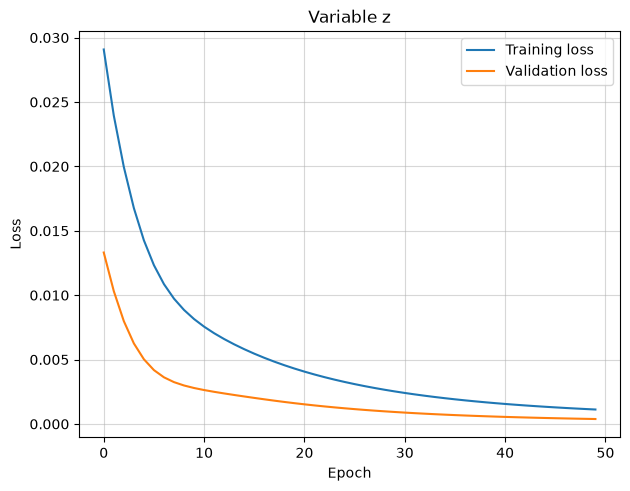

In [48]:
def plot_loss(history, title = None) -> None:
    """
    Plots the training loss curve from the history of a model
    """
    plt.plot(history["Loss"], label="Training loss")
    plt.plot(history["Val loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.legend()
    if title is not None:
        plt.title(title)
    plt.show()

plot_loss(histories[0], "Variable x")
plot_loss(histories[1], "Variable y")
plot_loss(histories[2], "Variable z")

In [25]:
# Evaluation mode
model_x.eval()
model_y.eval()
model_z.eval()

with torch.no_grad():
    pred_x = model_x(val_x).reshape(-1, 1)
    pred_y = model_y(val_y).reshape(-1, 1)
    pred_z = model_z(val_z).reshape(-1, 1)

# Stack predictions and targets: (n_samples, horizon, channels)
pred = torch.stack([pred_x, pred_y, pred_z], dim=2)
target = torch.stack([val_hor_x, val_hor_y, val_hor_z], dim=2)

# =====================
# RMSE
# =====================

squared_error = (pred - target) ** 2

# Per-sample RMSE, averaged over horizon and channels
mean_rmse_list = torch.sqrt(squared_error.mean(dim=(1, 2)))

# Global RMSE
mean_rmse_1 = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred - target)

# Per-sample MAE, averaged over horizon and channels
mean_mae_list = abs_error.mean(dim=(1, 2))

# Global MAE
mean_mae_1 = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target - pred) / (target + eps))

# Per-sample MAPE, averaged over horizon and channels
mean_mape_list = percentage_error.mean(dim=(1, 2))

# Global MAPE
mean_mape_1 = percentage_error.mean()

In [26]:
# Create a table to summarize the results
headers = ["Model", "MAPE", "MAE", "RMSE"]
results_short = [["VQC (indep.)", mean_mape_1, mean_mae_1, mean_rmse_1]]

print(30*"#")
print("Short term forecasting")
print(30*"#")
print(tabulate(results_short, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))

##############################
Short term forecasting
##############################
╒══════════════╤════════╤════════╤════════╕
│ Model        │   MAPE │    MAE │   RMSE │
╞══════════════╪════════╪════════╪════════╡
│ VQC (indep.) │ 0.0423 │ 0.0202 │ 0.0294 │
╘══════════════╧════════╧════════╧════════╛


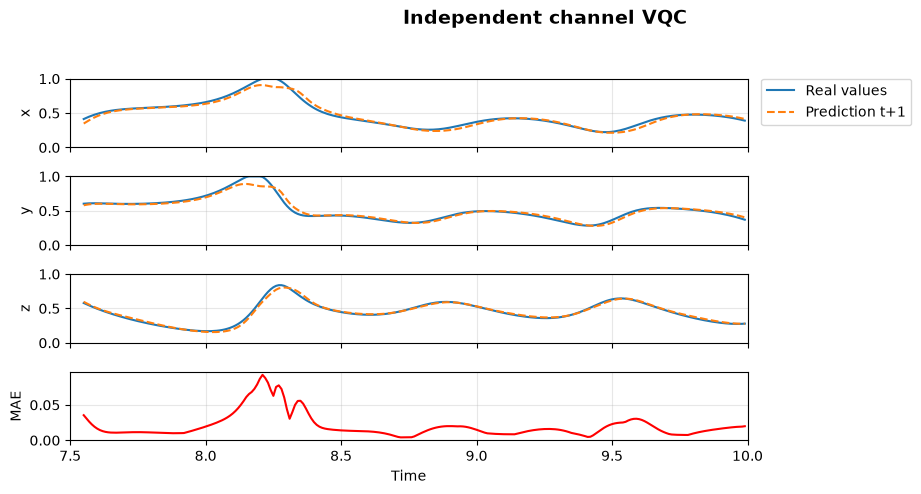

In [27]:
plot_preds_and_error(
    pred_x,
    pred_y,
    pred_z,
    mean_mae_list,
    time_val,
    window_size,
    val_scaled,
    error = "MAE",
    title="Independent channel VQC"
)

# VQC combined with MLP

In this section, we will use the same indepent-chanel architecture we used before and post-process it by appending a two-layer perceptron. We will use the RELU function and the mapping will be:

$$
\phi_{mlp}  :\mathbb{R^C} \rightarrow \mathbb{R^{2C\times S}} \rightarrow \mathbb{R^{C\times S}}
$$

This architecture supperts forecasting horizons $S>1$ simply by adjusting the output dimension of the final layer.

In [11]:
# Create the MLP post-processing model
class VQCMLPModel(nn.Module):
    def __init__(self, chanels, horizon):
        super().__init__()

        self.vqc_x = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)
        self.vqc_y = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)
        self.vqc_z = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)

        self.mlp = nn.Sequential(
            nn.Linear(chanels, 2*chanels*horizon),   
            nn.ReLU(),
            nn.Linear(2*chanels*horizon, chanels*horizon)     
        )

    def forward(self, x):
        # x shape: (batch, window_size, channels)
        x_ch = x[:, :, 0]
        y_ch = x[:, :, 1]
        z_ch = x[:, :, 2]

        qx = self.vqc_x(x_ch)
        qy = self.vqc_y(y_ch)
        qz = self.vqc_z(z_ch)

        q_features = torch.stack([qx, qy, qz], dim=1)

        return self.mlp(q_features)

## Short term forecasting

In [ ]:
# Create the sequences
window_size = 5
horizon_short = 1
batch_size = 128
n_chanels = 3

x_tr_short, hor_tr_short = create_sequences(train_scaled, window_size, horizon_short)
x_val_short, hor_val_short = create_sequences(val_scaled, window_size, horizon_short)

x_tr_short = torch.from_numpy(x_tr_short).double()
hor_tr_short = torch.from_numpy(hor_tr_short).double()

x_val_short = torch.from_numpy(x_val_short).double()
hor_val_short = torch.from_numpy(hor_val_short).double()

tr_dataset_short = TensorDataset(x_tr_short, hor_tr_short)
tr_loader_short = DataLoader(tr_dataset_short, batch_size=batch_size, shuffle=False)

In [ ]:
# Hyperparameters
epochs = 50
lr = 5e-4

# Create the model
model_VQCMLP_short = VQCMLPModel(n_chanels, horizon_short)
model_VQCMLP_short.double()

# Define optimizer and loss function
opt = torch.optim.Adam(params=model_VQCMLP_short.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state = None
best_val_loss = float("inf")

history = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_VQCMLP_short.train()
    epoch_loss = 0
    for xb, yb in tr_loader_short:
        opt.zero_grad()
        pred = model_VQCMLP_short(xb)
        target = yb.reshape(yb.shape[0], -1)
        loss = loss_fn(pred, target)    
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_short)
    history["Loss"].append(epoch_loss)

    # Evaluation
    model_VQCMLP_short.eval()
    with torch.no_grad():
        val_pred = model_VQCMLP_short(x_val_short)
        val_target = hor_val_short.reshape(hor_val_short.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            name: params.detach().clone()
            for name, params in model_VQCMLP_short.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state is not None:
    model_VQCMLP_short.load_state_dict(best_state)

In [ ]:
# Save the model
os.makedirs("models", exist_ok=True)

checkpoint = {
    "vqc_mlp_short": model_VQCMLP_short.state_dict(),
    "history": history
}
torch.save(checkpoint, "models/vqc_mlp_short.pt")

In [ ]:
# Load the model
checkpoint = torch.load(
    "models/vqc_mlp_short.pt",
    map_location="cpu"
)

history = checkpoint["history"]

model_VQCMLP_short = VQCMLPModel(n_chanels, horizon_short).double()
model_VQCMLP_short.load_state_dict(checkpoint["vqc_mlp_short"])

In [ ]:
plot_loss(history, "VQC + MLP short-term")

In [ ]:
# Evaluation mode
model_VQCMLP_short.eval()

with torch.no_grad():
    pred_short = model_VQCMLP_short(x_val_short)

pred_short_3d = pred_short.reshape(pred_short.shape[0], horizon_short, n_chanels)
target_short_3d = hor_val_short

# =====================
# RMSE
# =====================

squared_error = (pred_short_3d - target_short_3d) ** 2
mean_rmse_list = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse_2 = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_short_3d - target_short_3d)
mean_mae_list = abs_error.mean(dim=(1, 2))
mean_mae_2 = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_short_3d - pred_short_3d) / (target_short_3d + eps))
mean_mape_list = percentage_error.mean(dim=(1, 2))
mean_mape_2 = percentage_error.mean()

In [ ]:
# Create a table to summarize the results
headers = ["Model", "MAPE", "MAE", "RMSE"]
results_short.append(["VQC + MLP", mean_mape_2, mean_mae_2, mean_rmse_2])

print(30*"#")
print("Short term forecasting")
print(30*"#")
print(tabulate(results_short, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))

In [ ]:
pred_short_reshaped = pred_short.reshape(pred_short.shape[0], horizon_short, n_chanels)

pred_x_short = pred_short_reshaped[:, :, 0]
pred_y_short = pred_short_reshaped[:, :, 1]
pred_z_short = pred_short_reshaped[:, :, 2]

plot_preds_and_error(
    pred_x_short,
    pred_y_short,
    pred_z_short,
    mean_mae_list,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    horizon=horizon_short,
    horizon_step=1,
    title="VQC + MLP short-term"
)

# Long term forecasting

In [ ]:
# Create the sequences
window_size = 5
horizon_long = 5
batch_size = 128
n_chanels = 3

x_tr_long, hor_tr_long = create_sequences(train_scaled, window_size, horizon_long)
x_val_long, hor_val_long = create_sequences(val_scaled, window_size, horizon_long)

x_tr_long = torch.from_numpy(x_tr_long).double()
hor_tr_long = torch.from_numpy(hor_tr_long).double()

x_val_long = torch.from_numpy(x_val_long).double()
hor_val_long = torch.from_numpy(hor_val_long).double()

tr_dataset_long = TensorDataset(x_tr_long, hor_tr_long)
tr_loader_long = DataLoader(tr_dataset_long, batch_size=batch_size, shuffle=False)

In [ ]:
# Hyperparameters
epochs = 50
lr = 5e-4

# Create the model
model_VQCMLP_long = VQCMLPModel(n_chanels, horizon_long)
model_VQCMLP_long.double()

# Define optimizer and loss function
opt = torch.optim.Adam(params=model_VQCMLP_long.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state = None
best_val_loss = float("inf")

history = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_VQCMLP_long.train()
    epoch_loss = 0
    for xb, yb in tr_loader_long:
        opt.zero_grad()
        pred = model_VQCMLP_long(xb) # shape: (batch, 15)
        target = yb.reshape(yb.shape[0], -1) # yb shape: (batch, 5, 3)
        loss = loss_fn(pred, target)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_long)
    history["Loss"].append(epoch_loss)

    # Evaluation
    model_VQCMLP_long.eval()
    with torch.no_grad():
        val_pred = model_VQCMLP_long(x_val_long)
        val_target = hor_val_long.reshape(hor_val_long.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            name: params.detach().clone()
            for name, params in model_VQCMLP_long.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state is not None:
    model_VQCMLP_long.load_state_dict(best_state)

In [ ]:
# Save the model
os.makedirs("models", exist_ok=True)

checkpoint = {
    "vqc_mlp_long": model_VQCMLP_long.state_dict(),
    "history": history
}
torch.save(checkpoint, "models/vqc_mlp_long.pt")

In [ ]:
# Load the model
checkpoint = torch.load(
    "models/vqc_mlp_long.pt",
    map_location="cpu"
)

history = checkpoint["history"]

model_VQCMLP_long = VQCMLPModel(n_chanels, horizon_long).double()
model_VQCMLP_long.load_state_dict(checkpoint["vqc_mlp_long"])

In [ ]:
plot_loss(history, "VQC + MLP long-term")

In [ ]:
# Evaluation mode
model_VQCMLP_long.eval()

with torch.no_grad():
    pred_long = model_VQCMLP_long(x_val_long)

pred_long_3d = pred_long.reshape(pred_long.shape[0], horizon_long, n_chanels)
target_long_3d = hor_val_long

# =====================
# RMSE
# =====================

squared_error = (pred_long_3d - target_long_3d) ** 2
mean_rmse_list = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse_2 = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_long_3d - target_long_3d)
mean_mae_list = abs_error.mean(dim=(1, 2))
mean_mae_2 = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_long_3d - pred_long_3d) / (target_long_3d + eps))
mean_mape_list = percentage_error.mean(dim=(1, 2))
mean_mape_2 = percentage_error.mean()

In [ ]:
# Create a table to summarize the results
headers = ["Model", "MAPE", "MAE", "RMSE"]
results_long = [["VQC + MLP", mean_mape_2, mean_mae_2, mean_rmse_2]]

print(30*"#")
print("Long term forecasting")
print(30*"#")
print(tabulate(results_long, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))

In [ ]:
pred_x_long = pred_long_3d[:, :, 0]
pred_y_long = pred_long_3d[:, :, 1]
pred_z_long = pred_long_3d[:, :, 2]

plot_preds_and_error(
    pred_x_long,
    pred_y_long,
    pred_z_long,
    mean_mae_list,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    horizon=horizon_long,
    horizon_step=5,
    title="VQC + MLP long-term t+5"
)

# Dense embedding

Instead of using standard $R_y$ encoding, in this section we employ a dense embedding, which allows all three channels to be embedded in one qubit:

$$
|X_{t,1},X_{t,2},X_{t,3}\rangle = R_z (\pi X_{t,3}) R_y (\pi X_{t,2}) R_z(\pi X_{t,1}) |+\rangle
$$

We consider two variants for the output stage:

- Using a single qubit and assigning each channel to the expectation value of one of the Pauli operators $[\langle X \rangle, \langle Y \rangle, \langle Z \rangle]$.
- Measuring the Pauli-Z operator on three different qubits, each corresponding to one channel.

In the first variant the outputs are very coupled since they come from the same qubit. The second variant overcomes this limitation with the cost of higher number of qubits needed.